In [ ]:
# Capstone Project 1

## Introduction
This project analyses body measurement data of adult male and female participants using NumPy. The objective is to explore differences in body metrics using statistical methods and visualizations.

In [2]:
!pip install numpy matplotlib
import urllib.request

In [3]:
#checking if urllib is working or not
import urllib.request
print("urllib is working!")

urllib is working!


In [4]:
#Download Dataset
male_url = "https://raw.githubusercontent.com/gagolews/teaching-data/master/marek/nhanes_adult_male_bmx_2020.csv"
female_url = "https://raw.githubusercontent.com/gagolews/teaching-data/master/marek/nhanes_adult_female_bmx_2020.csv"

urllib.request.urlretrieve(male_url, "male.csv")
urllib.request.urlretrieve(female_url, "female.csv")

print("Download complete!")

Download complete!


In [52]:
#Load Data
#The datasets for male and female participants are downloaded directly from the source using Python code. This ensures reproducibility and eliminates the need for manual data handling. The CSV files are then loaded into NumPy arrays, which allow efficient numerical operations on multidimensional data.
import numpy as np

In [24]:
# Load Data
male = np.genfromtxt("male.csv", delimiter=",", skip_header=1)
female = np.genfromtxt("female.csv", delimiter=",", skip_header=1)

print("Male shape:", male.shape)
print("Female shape:", female.shape)

Male shape: (4082, 7)
Female shape: (4222, 7)


In [26]:
# Remove rows with NaN values
male = male[~np.isnan(male).any(axis=1)]
female = female[~np.isnan(female).any(axis=1)]

In [51]:
#Extract Columns
#Each dataset consists of seven columns representing body measurements such as weight, height, arm length, leg length, arm circumference, hip circumference, and waist circumference. NumPy slicing is used to extract relevant columns such as weight and height for further analysis.
male_weights = male[:, 0]
female_weights = female[:, 0]

male_height = male[:, 1]
female_height = female[:, 1]

In [50]:
#Histogram Analysis
#Histograms are plotted to visualize the distribution of weights for both male and female participants. The same x-axis limits are used for both plots to ensure a fair comparison. It is observed that male weights tend to be higher and more spread out compared to female weights, indicating greater variability.
import matplotlib.pyplot as plt

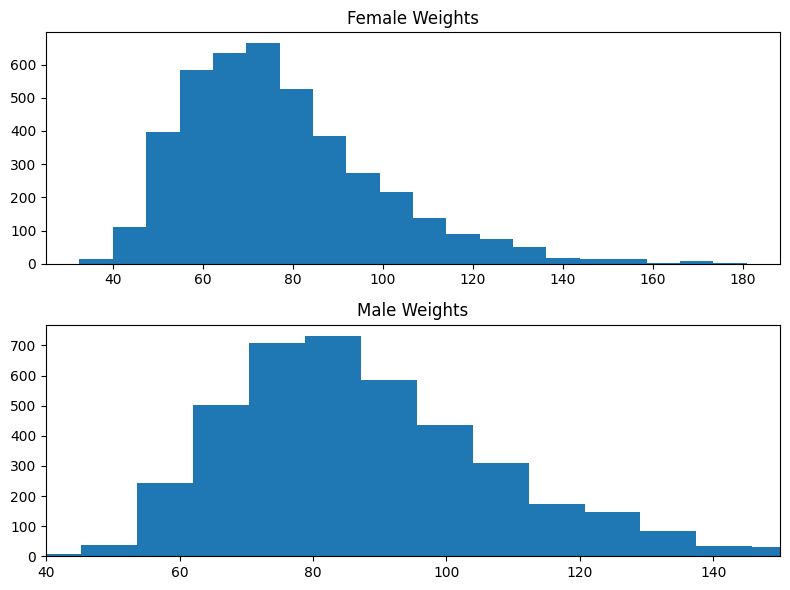

In [29]:
plt.figure(figsize=(8,6))

plt.subplot(2,1,1)
plt.hist(female_weights, bins=20)
plt.title("Female Weights")

plt.subplot(2,1,2)
plt.hist(male_weights, bins=20)
plt.title("Male Weights")

plt.xlim(40,150)
plt.tight_layout()
plt.show()


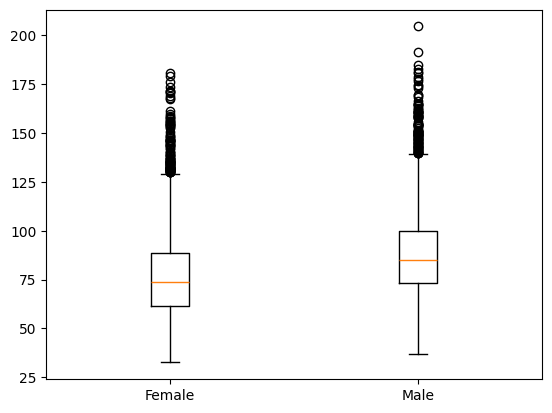

In [49]:
#Boxplot Comparision
#A box-and-whisker plot is used to compare the distribution of male and female weights. The median weight of males is higher than that of females. Additionally, the spread of male weights is larger, indicating higher variability. The presence of outliers can also be observed in both groups.
plt.boxplot([female_weights, male_weights])
plt.xticks([1,2], ["Female","Male"])
plt.show()

In [48]:
#Statistical Analysis
#Basic statistical measures such as mean, median, and standard deviation are computed using NumPy functions. The results show that males generally have a higher average weight and greater standard deviation, indicating more dispersion in their weight distribution. The median values also support this observation.
print("Female Mean:", np.mean(female_weights))
print("Male Mean:", np.mean(male_weights))

print("Female Std:", np.std(female_weights))
print("Male Std:", np.std(male_weights))

print("Female Median:", np.median(female_weights))
print("Male Median:", np.median(male_weights))

Female Mean: 77.40379057095475
Male Mean: 88.36454300416565
Female Std: 21.54250829019315
Male Std: 21.418936717962495
Female Median: 73.6
Male Median: 85.0


In [43]:
#BMI calculation
#Body Mass Index (BMI) is calculated for female participants using the formula weight divided by the square of height in meters. This new column is added to the dataset. BMI is a widely used measure to assess whether an individual has a healthy body weight relative to their height.
female_bmi = female_weights / ((female_height/100)**2)

female = np.column_stack((female, female_bmi))


In [46]:
#Standardization
#The dataset is standardized using z-scores, which transforms each feature to have a mean of 0 and a standard deviation of 1. This process ensures that all variables are on the same scale, making them comparable and suitable for further statistical analysis.
mean = np.mean(female, axis=0)
std = np.std(female, axis=0)

zfemale = (female - mean) / std

In [47]:
#Correlation Analysis
#Correlation between variables is computed using NumPy. It is observed that weight, waist circumference, and hip circumference are strongly positively correlated. This indicates that individuals with higher weight tend to have larger waist and hip measurements.
corr_matrix = np.corrcoef(female.T)
print(corr_matrix)

[[ 1.          0.34549627  0.55156338  0.19318571  0.90538509  0.94655347
   0.90455038  0.94590048  0.94590048]
 [ 0.34549627  1.          0.66791075  0.65720245  0.1519549   0.20289468
   0.12654714  0.03307725  0.03307725]
 [ 0.55156338  0.66791075  1.          0.475645    0.45312216  0.45939973
   0.42789262  0.36466006  0.36466006]
 [ 0.19318571  0.65720245  0.475645    1.          0.07987579  0.10026843
  -0.03480285 -0.01481855 -0.01481855]
 [ 0.90538509  0.1519549   0.45312216  0.07987579  1.          0.86806275
   0.84506542  0.91538778  0.91538778]
 [ 0.94655347  0.20289468  0.45939973  0.10026843  0.86806275  1.
   0.89740696  0.94419901  0.94419901]
 [ 0.90455038  0.12654714  0.42789262 -0.03480285  0.84506542  0.89740696
   1.          0.92119833  0.92119833]
 [ 0.94590048  0.03307725  0.36466006 -0.01481855  0.91538778  0.94419901
   0.92119833  1.          1.        ]
 [ 0.94590048  0.03307725  0.36466006 -0.01481855  0.91538778  0.94419901
   0.92119833  1.          1. 

In [40]:
#Ratio Analysis
#Two important ratios are calculated: waist-to-height ratio and waist-to-hip ratio. These ratios provide better insights into fat distribution and potential health risks compared to BMI alone. They are computed for both male and female participants.
male_waist = male[:,6]
male_hip = male[:,5]

female_waist = female[:,6]
female_hip = female[:,5]

male_wht = male_waist / male_height
male_whr = male_waist / male_hip

female_wht = female_waist / female_height
female_whr = female_waist / female_hip

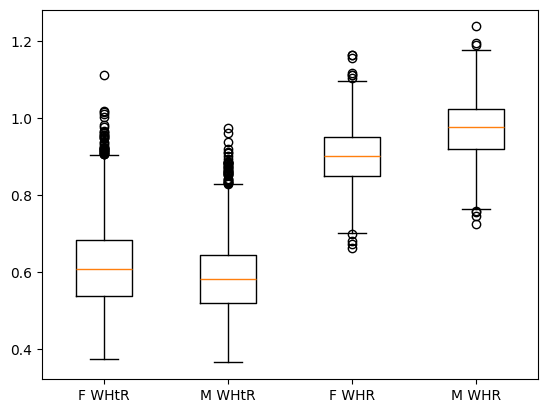

In [39]:
#Final Boxplot comparision
#A boxplot comparing waist-to-height and waist-to-hip ratios for both genders is created. The results show noticeable differences in fat distribution patterns between males and females. These ratios are useful indicators of health risks such as cardiovascular diseases.
plt.boxplot([female_wht, male_wht, female_whr, male_whr])
plt.xticks([1,2,3,4], ["F WHtR","M WHtR","F WHR","M WHR"])
plt.show()

In [38]:
#Extreme BMI Analysis

#The individuals with the lowest and highest BMI values are identified using NumPy’s sorting functions. Their standardized measurements are examined to understand how body proportions differ at extreme BMI levels. Individuals with high BMI tend to have significantly higher waist and hip measurements.

sorted_idx = np.argsort(female_bmi)

lowest = zfemale[sorted_idx[:5]]
highest = zfemale[sorted_idx[-5:]]

print("Lowest BMI:\n", lowest)
print("Highest BMI:\n", highest)

Lowest BMI:
 [[-2.07978523 -1.22299143 -1.5478402  -1.16905675 -2.1947611  -2.0405496
  -1.94212128 -2.05024028]
 [-1.88017988 -0.18929313 -1.71835247  0.38637892 -2.4443617  -1.85491922
  -2.05708015 -1.99487987]
 [-1.53667299  1.80730222  0.62619127  0.5730312  -2.26607556 -1.6756899
  -1.7064556  -1.97088383]
 [-1.843044   -0.26009438 -0.22637009  0.51081377 -2.30173278 -2.25178417
  -1.85590213 -1.94177591]
 [-1.61094475  0.88688592 -0.09848588  0.47970506 -2.21258971 -1.82931504
  -1.71220354 -1.89319577]]
Highest BMI:
 [[ 4.2472403   0.29215539  1.86240524 -0.98240447  2.3693641   4.10445598
   3.81731803  4.39649161]
 [ 4.45612963  0.50455915  1.69189297 -1.13794804  3.34993787  3.98283607
   2.90339503  4.46201122]
 [ 4.34936397  0.27799514  2.84285081  1.94181459  4.36616887  3.9188256
   3.75409065  4.51466896]
 [ 4.8042785   0.88688592  2.11817365  1.81737973  3.77782461  4.02124236
   4.08172343  4.54270932]
 [ 4.36328993 -0.03353037 -0.05585782 -0.17357792  2.77942222  4.3

In [ ]:
#Conclusion
#This project demonstrated the use of NumPy for analysing multidimensional health data. It was observed that male participants generally have higher weight and variability compared to females. While BMI provides a basic measure of body composition, ratios such as waist-to-height and waist-to-hip offer better insights into fat distribution and health risks. Overall, combining statistical analysis with visualization helps in understanding differences between groups effectively.